In [ ]:
#Imports
import os
import numpy as np
import pandas as pd
from scipy.io import wavfile
from scipy import signal

# Define output directory for spectrogram files and create it if not exists
output_dir = 'spectrogram_output'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

def load_audio_and_annotation(file_base_name):
    # Load the WAV audio file
    audio_path = file_base_name + '.wav'
    sample_rate, samples = wavfile.read(audio_path)
    
    # Load the annotation file (typically .txt or .csv)
    annot_file_path = file_base_name + '.Table.1.selections.txt'
    df = pd.read_csv(annot_file_path, sep='\t')
    
    return sample_rate, samples, df

def extract_audio_segments(samples, sample_rate, annotations):
    segments = []
    for _, row in annotations.iterrows():
        start_time, end_time = row['Begin Time (s)'], row['End Time (s)']
        start_sample, end_sample = int(start_time * sample_rate), int(end_time * sample_rate)
        segment = samples[start_sample:end_sample]
        segments.append({
            'Selection': row['Selection'],
            'Annotation': row['Annotation'],
            'Begin Time (s)': start_time,
            'End Time (s)': end_time,
            'audio_segment': segment,
            'Low Freq (Hz)': row['Low Freq (Hz)'],
            'High Freq (Hz)': row['High Freq (Hz)']
        })
    return segments


# Reference code https://stackoverflow.com/questions/38015319/how-to-create-a-numpy-array-from-a-pydub-audiosegment
def generate_spectrogram(audio_segment, sample_rate, fmin=20, fmax=1000, nperseg=2456, nfft=4096, noverlap=1228):
    """
    Generate spectrogram for a given audio segment based on frequency range (fmin, fmax).
    
    Parameters:
        - audio_segment (np.array): The raw audio data.
        - sample_rate (int): The sampling rate of the audio data.
        - fmin (int): The minimum frequency for the spectrogram. Default is 20 Hz.
        - fmax (int): The maximum frequency for the spectrogram. Default is 1000 Hz.
        - nperseg (int): The length of each segment for the FFT. Default is 2456 samples.
        - nfft (int): The number of FFT points. Default is 4096.
        - noverlap (int): The number of points to overlap between segments. Default is 1228.

    Returns:
        - frequencies (np.array): Frequency bins for the spectrogram.
        - times (np.array): Time bins for the spectrogram.
        - spectrogram_data (np.array): 2D spectrogram array.
    """
    # Generate the spectrogram using scipy.signal.spectrogram
    frequencies, times, spectrogram_data = signal.spectrogram(audio_segment, sample_rate, 
                                                              nperseg=nperseg, nfft=nfft, 
                                                              noverlap=noverlap, window='hann')
    
    # Threshold tiny values in the spectrogram (to avoid plotting issues) 
    spectrogram_data[spectrogram_data < 0.001] = 0.001
    
    # Slice the frequencies based on the desired range (fmin to fmax)
    freq_slice = np.where((frequencies >= fmin) & (frequencies <= fmax))
    frequencies = frequencies[freq_slice]
    spectrogram_data = spectrogram_data[freq_slice, :]
    
    return frequencies, times, spectrogram_data

def generate_spectrogram(audio_segment, sample_rate, fmin=20, fmax=1000, nperseg=2456, nfft=4096, noverlap=1228):
    frequencies, times, spectrogram_data = signal.spectrogram(
        audio_segment, sample_rate, nperseg=nperseg, nfft=nfft, noverlap=noverlap, window='hann')
    spectrogram_data[spectrogram_data < 0.001] = 0.001
    freq_slice = np.where((frequencies >= fmin) & (frequencies <= fmax))
    frequencies, spectrogram_data = frequencies[freq_slice], spectrogram_data[freq_slice, :]
    return frequencies, times, spectrogram_data

def calculate_baselines(folder_paths):
    # Initialize global variables to store the maximum segment duration and frequency range
    global baseline_time, baseline_freq
    
    # Initialize variables to track the maximum duration and frequency range across all files
    max_duration, max_freq_range = 0, (float('inf'), 0)
    
    # Iterate through each folder in the folder_paths list
    for folder_path in folder_paths:
        # Loop through each file in the current folder
        for file in os.listdir(folder_path):
            # Only process files that end with '.Table.1.selections.txt' (annotation files)
            if file.endswith('.Table.1.selections.txt'):
                
                # Load the annotation file as a dataframe
                df = pd.read_csv(os.path.join(folder_path, file), sep='\t')
                
                # Calculate the duration of each segment (End Time - Begin Time)
                durations = df['End Time (s)'] - df['Begin Time (s)']
                
                # Update the maximum duration encountered so far
                max_duration = max(max_duration, durations.max())
                
                # Get the minimum and maximum frequency values for the current file
                low_freq, high_freq = df['Low Freq (Hz)'].min(), df['High Freq (Hz)'].max()
                
                # Update the frequency range to include the current file's frequency values
                max_freq_range = (min(max_freq_range[0], low_freq), max(max_freq_range[1], high_freq))
    
    # Set the global baseline_time and baseline_freq with the maximum duration and frequency range
    baseline_time, baseline_freq = max_duration, max_freq_range

def pad_or_crop_spectrogram(spectrogram_data, sample_rate, max_time_bins=2000):
    # Remove singleton dimensions if they exist (e.g., a 1D spectrogram)
    # Source: https://numpy.org/doc/stable/reference/generated/numpy.squeeze.html
    spectrogram_data = np.squeeze(spectrogram_data)
    
    # If the spectrogram has fewer than 2 dimensions, reshape it into a 2D array (1 x n)
    # Source: https://numpy.org/doc/stable/reference/generated/numpy.reshape.html
    if len(spectrogram_data.shape) < 2:
        spectrogram_data = spectrogram_data.reshape(-1, 1)

    # If the spectrogram is still 1D, reshape it into 2D: (1, n)
    # Source: https://numpy.org/doc/stable/reference/generated/numpy.reshape.html
    if len(spectrogram_data.shape) == 1:
        spectrogram_data = spectrogram_data.reshape(1, -1)

    # Retrieve the current number of frequency bins and time bins from the spectrogram shape
    current_frequency_bins, current_time_bins = spectrogram_data.shape

    # Calculate the target number of time bins based on baseline duration and sample rate
    # Source: https://numpy.org/doc/stable/reference/generated/numpy.linspace.html
    target_time_bins = int(baseline_time * sample_rate / spectrogram_data.shape[0])
    
    # Set the maximum time bins to `max_time_bins` (limit the maximum size)
    target_time_bins = min(target_time_bins, max_time_bins)

    # Padding for the time dimension (add zeros to match the target_time_bins)
    # Source: https://numpy.org/doc/stable/reference/generated/numpy.pad.html
    padding_width = target_time_bins - current_time_bins
    if padding_width > 0:
        # If padding is needed, add zeros along the time axis
        spectrogram_data = np.pad(
            spectrogram_data,
            pad_width=((0, 0), (0, padding_width)),
            mode='constant', constant_values=0
        )
    elif current_time_bins > target_time_bins:
        # If the spectrogram is too large, crop it to the target size
        spectrogram_data = spectrogram_data[:, :target_time_bins]

    # Frequency axis resizing if necessary
    # Calculate the number of frequency bins based on baseline frequency range
    target_frequency_bins = len(np.linspace(baseline_freq[0], baseline_freq[1], spectrogram_data.shape[0]))
    
    current_frequency_bins = spectrogram_data.shape[0]
    if current_frequency_bins < target_frequency_bins:
        # If there are fewer frequency bins than required, add zero padding
        frequency_padding = target_frequency_bins - current_frequency_bins
        spectrogram_data = np.pad(
            spectrogram_data,
            pad_width=((frequency_padding, 0), (0, 0)),
            mode='constant', constant_values=0
        )
    elif current_frequency_bins > target_frequency_bins:
        # If there are more frequency bins than required, crop the spectrogram
        spectrogram_data = spectrogram_data[:target_frequency_bins, :]

    # Return the padded or cropped spectrogram
    return spectrogram_data


def create_no_call_segments(samples, sample_rate, annotations):
    # Initialize an empty list to store the 'no call' segments 
    #Source: https://stackoverflow.com/questions/50310527/accessing-table-view-cell-information-from-another-view-controller-in-swift/50312258#50312258
    no_call_segments = []
    # Track the last end time of an annotation to determine the gaps between calls
    last_end_time = 0
    
    # Iterate over each row (each annotation) in the annotations DataFrame
    for _, row in annotations.iterrows():
        start_time = row['Begin Time (s)']
        # If there is a gap (the start of the current annotation is after the last end time)
        if start_time > last_end_time:
            # Extract the segment of audio between the previous annotation end and the current annotation start
            no_call_segment = samples[int(last_end_time * sample_rate):int(start_time * sample_rate)]
            no_call_segments.append(no_call_segment)
        
        # Update the last_end_time to be the later of the current or previous end time
        last_end_time = max(last_end_time, row['End Time (s)'])
    
    # If the last annotation doesn't cover the entire audio, add the remaining 'no-call' segment
    if last_end_time < len(samples) / sample_rate:
        no_call_segment = samples[int(last_end_time * sample_rate):]
        no_call_segments.append(no_call_segment)
    
    # Return the list of extracted 'no-call' segments
    return no_call_segments


def get_category_name(folder_path):
    if 'Guttural rupe' in folder_path:
        return 'guttural_rupe'
    elif 'Rupes A and B' in folder_path:
        return 'rupe_A_and_B'
    elif 'Moan' in folder_path:
        return 'moan'
    else:
        return 'unknown_category'
    
folder_paths = [
    r'C:\Users\Admin\Downloads\Samples Grey Seal\Guttural rupe',
    r'C:\Users\Admin\Downloads\Samples Grey Seal\Rupes A and B',
    r'C:\Users\Admin\Downloads\Samples Grey Seal\Moan'
]

calculate_baselines(folder_paths)
dataset = []

# Extracting segments
for folder_path in folder_paths:
    category = get_category_name(folder_path)  # Get the category based on the folder path

    # Create subfolder for the category if it doesn't exist
    category_output_dir = os.path.join(output_dir, category)
    if not os.path.exists(category_output_dir):
        os.makedirs(category_output_dir)

    for file in os.listdir(folder_path):
        if file.endswith('.wav'):
            file_base_name = os.path.splitext(file)[0]
            file_base_path = os.path.join(folder_path, file_base_name)
            sample_rate, samples, df = load_audio_and_annotation(file_base_path)
            segments = extract_audio_segments(samples, sample_rate, df)

            # Add the category column to each segment dataframe
            for segment in segments:
                segment['Category'] = category
            dataset.append(pd.DataFrame(segments))

final_df = pd.concat(dataset, ignore_index=True)

# --- Generate and save spectrograms for calls ---
for index, segment_info in final_df.iterrows():
    audio_segment = segment_info['audio_segment']
    frequencies, times, spectrogram_data = generate_spectrogram(
        audio_segment, sample_rate, fmin=segment_info['Low Freq (Hz)'], fmax=segment_info['High Freq (Hz)']
    )

    # Apply padding or cropping based on the baseline
    spectrogram_data = pad_or_crop_spectrogram(spectrogram_data, sample_rate)

    metadata = {
        'Selection': segment_info['Selection'],
        'Annotation': segment_info['Annotation'],
        'Category': segment_info['Category'],
        'Spectrogram Shape': spectrogram_data.shape
    }
    
    # Save the file in the corresponding subfolder
    np.savez(
        os.path.join(category_output_dir, f"{segment_info['Selection']}_spectrogram.npz"),
        spectrogram=spectrogram_data, metadata=metadata
    )

# --- Generate and save no-call spectrograms --- 
no_call_segments = create_no_call_segments(samples, sample_rate, final_df)
no_calls_output_dir = os.path.join(output_dir, "no_calls")
if not os.path.exists(no_calls_output_dir):
    os.makedirs(no_calls_output_dir)

for idx, no_call_segment in enumerate(no_call_segments):
    frequencies, times, spectrogram_data = generate_spectrogram(
        no_call_segment, sample_rate, fmin=baseline_freq[0], fmax=baseline_freq[1]
    )

    # Apply padding or cropping based on the baseline
    spectrogram_data = pad_or_crop_spectrogram(spectrogram_data, sample_rate)

    metadata = {'Selection': f"no-call_{idx}", 'Annotation': "No Call", 'Category': "no_calls", 'Spectrogram Shape': spectrogram_data.shape}
    
    # Save the no-call spectrogram with the 'no_calls' category
    np.savez(
        os.path.join(no_calls_output_dir, f"no_call_{idx}_spectrogram.npz"),
        spectrogram=spectrogram_data, metadata=metadata
    )

print(f"Saved spectrograms and metadata to {output_dir}")



C:\Users\Admin\AppData\Local\Temp\ipykernel_12880\770076.py:41: UserWarning: nperseg = 2456 is greater than input length  = 2192, using nperseg = 2192
  frequencies, times, spectrogram_data = signal.spectrogram(audio_segment, sample_rate,


Saved spectrograms and metadata to spectrogram_output


In [11]:
import os
import numpy as np
import pandas as pd
from scipy.io import wavfile
from scipy import signal

# Define output directory for spectrogram files and create it if not exists
output_dir = 'spectrogram_output'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

def load_audio_and_annotation(file_base_name):
    # Load the WAV audio file
    audio_path = file_base_name + '.wav'
    sample_rate, samples = wavfile.read(audio_path)
    
    # Load the annotation file (typically .txt or .csv)
    annot_file_path = file_base_name + '.Table.1.selections.txt'
    df = pd.read_csv(annot_file_path, sep='\t')
    
    return sample_rate, samples, df

def extract_audio_segments(samples, sample_rate, annotations):
    segments = []
    for _, row in annotations.iterrows():
        start_time, end_time = row['Begin Time (s)'], row['End Time (s)']
        start_sample, end_sample = int(start_time * sample_rate), int(end_time * sample_rate)
        segment = samples[start_sample:end_sample]
        segments.append({
            'Selection': row['Selection'],
            'Annotation': row['Annotation'],
            'Begin Time (s)': start_time,
            'End Time (s)': end_time,
            'audio_segment': segment,
            'Low Freq (Hz)': row['Low Freq (Hz)'],
            'High Freq (Hz)': row['High Freq (Hz)']
        })
    return segments

def generate_spectrogram(audio_segment, sample_rate, fmin=20, fmax=1000, nperseg=2456, nfft=4096, noverlap=1228):
    frequencies, times, spectrogram_data = signal.spectrogram(
        audio_segment, sample_rate, nperseg=nperseg, nfft=nfft, noverlap=noverlap, window='hann')
    spectrogram_data[spectrogram_data < 0.001] = 0.001
    freq_slice = np.where((frequencies >= fmin) & (frequencies <= fmax))
    frequencies, spectrogram_data = frequencies[freq_slice], spectrogram_data[freq_slice, :]
    return frequencies, times, spectrogram_data

def get_category_name(annotation):
    # Define category based on annotations
    if annotation == 'Rupe A':
        return 'rupe_A'
    elif annotation == 'Rupe B':
        return 'rupe_B'
    elif annotation == 'Rupe C':
        return 'rupe_C'
    elif annotation == 'Growl B':
        return 'growl_B'
    elif annotation == 'Moan':
        return 'moan'
    elif annotation == 'G rupe':
        return 'g_rupe'
    else:
        return 'unknown'

# Set the folder paths
folder_paths = [
    r'C:\Users\Admin\Downloads\Samples Grey Seal\Guttural rupe',
    r'C:\Users\Admin\Downloads\Samples Grey Seal\Rupes A and B',
    r'C:\Users\Admin\Downloads\Samples Grey Seal\Moan'
]

dataset = []

# Extracting segments
for folder_path in folder_paths:
    for file in os.listdir(folder_path):
        if file.endswith('.wav'):
            file_base_name = os.path.splitext(file)[0]
            file_base_path = os.path.join(folder_path, file_base_name)
            sample_rate, samples, df = load_audio_and_annotation(file_base_path)
            segments = extract_audio_segments(samples, sample_rate, df)

            # Categorizing the segments based on annotation and add category info to dataframe
            for segment in segments:
                category = get_category_name(segment['Annotation'])
                segment['Category'] = category
                dataset.append(pd.DataFrame([segment]))

# Merge all dataset parts into final dataset
final_df = pd.concat(dataset, ignore_index=True)

# --- Generate and save spectrograms for calls ---
for index, segment_info in final_df.iterrows():
    audio_segment = segment_info['audio_segment']
    frequencies, times, spectrogram_data = generate_spectrogram(
        audio_segment, sample_rate, fmin=segment_info['Low Freq (Hz)'], fmax=segment_info['High Freq (Hz)']
    )

    # Save the spectrogram in the corresponding category directory
    category_output_dir = os.path.join(output_dir, segment_info['Category'])
    if not os.path.exists(category_output_dir):
        os.makedirs(category_output_dir)

    np.savez(
        os.path.join(category_output_dir, f"{segment_info['Selection']}_spectrogram.npz"),
        spectrogram=spectrogram_data, metadata=segment_info.to_dict()
    )

# --- Generate and save no-call spectrograms --- 
no_call_segments = create_no_call_segments(samples, sample_rate, final_df)
no_calls_output_dir = os.path.join(output_dir, "no_calls")
if not os.path.exists(no_calls_output_dir):
    os.makedirs(no_calls_output_dir)

for idx, no_call_segment in enumerate(no_call_segments):
    frequencies, times, spectrogram_data = generate_spectrogram(
        no_call_segment, sample_rate, fmin=baseline_freq[0], fmax=baseline_freq[1]
    )

    np.savez(
        os.path.join(no_calls_output_dir, f"no_call_{idx}_spectrogram.npz"),
        spectrogram=spectrogram_data, metadata={'Selection': f"no-call_{idx}", 'Annotation': "No Call"}
    )

print(f"Saved spectrograms and metadata to {output_dir}")


C:\Users\Admin\AppData\Local\Temp\ipykernel_12880\3072291393.py:41: UserWarning: nperseg = 2456 is greater than input length  = 2192, using nperseg = 2192
  frequencies, times, spectrogram_data = signal.spectrogram(


Saved spectrograms and metadata to spectrogram_output


In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy import signal
from matplotlib.colors import LogNorm

# To enable zooming in matplotlib in notebook
# %matplotlib notebook
# conda install -c conda-forge ipympl # or pip install ipympl
%matplotlib ipympl

# Define output directory for spectrogram files and create it if not exists
output_dir = 'spectrogram_output'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Set the folder paths
folder_paths = [
    r'C:\Users\Admin\Downloads\Samples Grey Seal\Guttural rupe',
    r'C:\Users\Admin\Downloads\Samples Grey Seal\Rupes A and B',
    r'C:\Users\Admin\Downloads\Samples Grey Seal\Moan'
]

annotation_colors = {
    "Rupe A": "red",
    "Rupe B": "green",
    "Growl B": "yellow",
    "Rupe C": "purple",
    "Moan": "pink",
    "G rupe": "blue"
}

def load_audio_and_annotation(file_base_name):
    # Load the WAV audio file
    audio_path = file_base_name + '.wav'
    sample_rate, samples = wavfile.read(audio_path)
    
    # Load the annotation file (typically .txt or .csv)
    annot_file_path = file_base_name + '.Table.1.selections.txt'
    df = pd.read_csv(annot_file_path, sep='\t')
    
    return sample_rate, samples, df

def extract_audio_segments(samples, sample_rate, annotations):
    segments = []
    for _, row in annotations.iterrows():
        start_time, end_time = row['Begin Time (s)'], row['End Time (s)']
        start_sample, end_sample = int(start_time * sample_rate), int(end_time * sample_rate)
        segment = samples[start_sample:end_sample]
        segments.append({
            'Selection': row['Selection'],
            'Annotation': row['Annotation'],
            'Begin Time (s)': start_time,
            'End Time (s)': end_time,
            'audio_segment': segment,
            'Low Freq (Hz)': row['Low Freq (Hz)'],
            'High Freq (Hz)': row['High Freq (Hz)']
        })
    return segments

def generate_spectrogram(audio_segment, sample_rate, fmin=20, fmax=1000, nperseg=2456, nfft=4096, noverlap=1228):
    frequencies, times, spectrogram_data = signal.spectrogram(
        audio_segment, sample_rate, nperseg=nperseg, nfft=nfft, noverlap=noverlap, window='hann')
    spectrogram_data[spectrogram_data < 0.001] = 0.001
    freq_slice = np.where((frequencies >= fmin) & (frequencies <= fmax))
    frequencies, spectrogram_data = frequencies[freq_slice], spectrogram_data[freq_slice, :]
    return frequencies, times, spectrogram_data

def overlay_annotations(ax, df, annotation_colors):
    # Track labels to ensure they are added only once in the legend
    added_labels = set()

    for _, row in df.iterrows():
        start_time = row['Begin Time (s)']
        end_time = row['End Time (s)']
        low_freq = row['Low Freq (Hz)']
        high_freq = row['High Freq (Hz)']
        annotation = row['Annotation']

        # Skip if the annotation is not in the defined colors
        if annotation not in annotation_colors:
            continue

        # Draw rectangles
        ax.add_patch(
            plt.Rectangle(
                (start_time, low_freq),  # Bottom Left corner
                end_time - start_time,  # Width (time)
                high_freq - low_freq,  # Height (frequency)
                edgecolor=annotation_colors[annotation],
                facecolor='none',
                linewidth=2,
                label=annotation if annotation not in added_labels else None  # Add label only once
            )
        )
        added_labels.add(annotation)  # Mark label as added

    ax.legend(loc='upper right')  # Add legend

# Function to update colormap limits during zoom
def update_colormap(event):
    # Get current view limits
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Find indices corresponding to the current view limits
    x_indices = np.where((times >= xlim[0]) & (times <= xlim[1]))[0]
    y_indices = np.where((frequencies >= ylim[0]) & (frequencies <= ylim[1]))[0]

    # Handle cases where no data is visible
    if len(x_indices) == 0 or len(y_indices) == 0:
        return

    # Extract the visible data
    data_visible = spectrogram[np.ix_(y_indices, x_indices)]

    # Compute new color limits
    vmin = np.nanmin(data_visible)
    vmax = np.nanmax(data_visible)

    # Update the color limits of the pcolormesh
    pc.set_clim(vmin=vmin, vmax=vmax)
    
    # Update the colorbar to reflect the new color limits
    cbar.update_normal(pc)

    # Redraw the figure
    plt.draw()

def get_category_name(annotation):
    # Define category based on annotations
    if annotation == 'Rupe A':
        return 'rupe_A'
    elif annotation == 'Rupe B':
        return 'rupe_B'
    elif annotation == 'Rupe C':
        return 'rupe_C'
    elif annotation == 'Growl B':
        return 'growl_B'
    elif annotation == 'Moan':
        return 'moan'
    elif annotation == 'G rupe':
        return 'g_rupe'
    else:
        return 'unknown'

# Extract segments, categorize, and generate spectrograms
dataset = []
for folder_path in folder_paths:
    for file in os.listdir(folder_path):
        if file.endswith('.wav'):
            file_base_name = os.path.splitext(file)[0]
            file_base_path = os.path.join(folder_path, file_base_name)
            sample_rate, samples, df = load_audio_and_annotation(file_base_path)
            segments = extract_audio_segments(samples, sample_rate, df)

            # Categorize the segments based on annotation
            for segment in segments:
                category = get_category_name(segment['Annotation'])
                segment['Category'] = category
                dataset.append(pd.DataFrame([segment]))

# Merge all dataset parts into final dataset
final_df = pd.concat(dataset, ignore_index=True)

# Now plot for the last generated spectrogram, for visualization
for index, segment_info in final_df.iterrows():
    audio_segment = segment_info['audio_segment']
    frequencies, times, spectrogram = generate_spectrogram(
        audio_segment, sample_rate, fmin=segment_info['Low Freq (Hz)'], fmax=segment_info['High Freq (Hz)']
    )

    # Generate spectrogram plot
    pc = plt.pcolormesh(times, frequencies, spectrogram, norm=LogNorm(), cmap='Spectral_r')
    cbar = plt.colorbar(pc)
    plt.ylabel('Frequency [Hz]')
    plt.xlabel('Time [sec]')

    # Get the current axes
    ax = plt.gca()
    overlay_annotations(ax, final_df, annotation_colors)

    # Connect the update function to the axes limit change events
    ax.callbacks.connect('xlim_changed', update_colormap)
    ax.callbacks.connect('ylim_changed', update_colormap)

    plt.show()
    
    # Store spectrograms in the corresponding category directory
    category_output_dir = os.path.join(output_dir, segment_info['Category'])
    if not os.path.exists(category_output_dir):
        os.makedirs(category_output_dir)
    
    np.savez(
        os.path.join(category_output_dir, f"{segment_info['Selection']}_spectrogram.npz"),
        spectrogram=spectrogram, metadata=segment_info.to_dict()
    )

print(f"Saved spectrograms and metadata to {output_dir}")


TypeError: Dimensions of C (1, 5, 39) should be one smaller than X(39) and Y(5) while using shading='flat' see help(pcolormesh)

TypeError: Dimensions of C (3, 2000) should be one smaller than X(96) and Y(3) while using shading='flat' see help(pcolormesh)

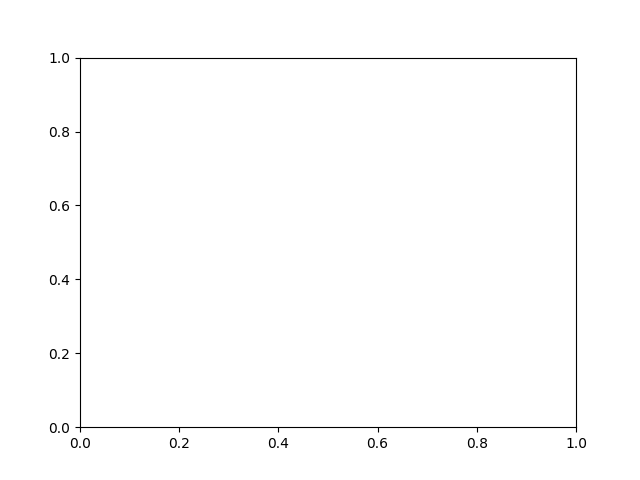

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy import signal
from matplotlib.colors import LogNorm

# %matplotlib ipympl for interactive zooming in Jupyter
%matplotlib ipympl

# Define output directory for spectrogram files and create it if not exists
output_dir = 'spectrogram_output'
os.makedirs(output_dir, exist_ok=True)

# Set folder paths
folder_paths = [
    r'C:\Users\Admin\Downloads\Samples Grey Seal\Guttural rupe',
    r'C:\Users\Admin\Downloads\Samples Grey Seal\Rupes A and B',
    r'C:\Users\Admin\Downloads\Samples Grey Seal\Moan'
]

annotation_colors = {
    "Rupe A": "red",
    "Rupe B": "green",
    "Growl B": "yellow",
    "Rupe C": "purple",
    "Moan": "pink",
    "G rupe": "blue"
}

# Global variables for baselines
baseline_time, baseline_freq = None, None

# Function to load audio and annotation
def load_audio_and_annotation(file_base_path):
    audio_path = file_base_path + '.wav'
    annot_file_path = file_base_path + '.Table.1.selections.txt'
    sample_rate, samples = wavfile.read(audio_path)
    df = pd.read_csv(annot_file_path, sep='\t')
    return sample_rate, samples, df

# Function to extract audio segments
def extract_audio_segments(samples, sample_rate, annotations):
    segments = []
    for _, row in annotations.iterrows():
        start_time, end_time = row['Begin Time (s)'], row['End Time (s)']
        start_sample, end_sample = int(start_time * sample_rate), int(end_time * sample_rate)
        segment = samples[start_sample:end_sample]
        segments.append({
            'Selection': row['Selection'],
            'Annotation': row['Annotation'],
            'Begin Time (s)': start_time,
            'End Time (s)': end_time,
            'audio_segment': segment,
            'Low Freq (Hz)': row['Low Freq (Hz)'],
            'High Freq (Hz)': row['High Freq (Hz)']
        })
    return segments

# Function to generate spectrogram
def generate_spectrogram(audio_segment, sample_rate, fmin=20, fmax=1000, nperseg=1024, nfft=2048, noverlap=512):
    frequencies, times, spectrogram_data = signal.spectrogram(
        audio_segment, sample_rate, nperseg=nperseg, nfft=nfft, noverlap=noverlap, window='hann'
    )
    spectrogram_data = np.maximum(spectrogram_data, 1e-10)
    freq_slice = np.where((frequencies >= fmin) & (frequencies <= fmax))
    return frequencies[freq_slice], times, spectrogram_data[freq_slice]

# Function to overlay annotations
def overlay_annotations(ax, annotations, annotation_colors):
    for _, row in annotations.iterrows():
        if row['Annotation'] in annotation_colors:
            rect = plt.Rectangle(
                (row['Begin Time (s)'], row['Low Freq (Hz)']),
                row['End Time (s)'] - row['Begin Time (s)'],
                row['High Freq (Hz)'] - row['Low Freq (Hz)'],
                edgecolor=annotation_colors[row['Annotation']],
                facecolor='none', linewidth=2
            )
            ax.add_patch(rect)
    ax.legend(handles=[plt.Line2D([0], [0], color=color, label=key, lw=2)
                        for key, color in annotation_colors.items()],
              loc='upper right')

# Update colormap dynamically
def update_colormap(event):
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    x_indices = np.where((times >= xlim[0]) & (times <= xlim[1]))[0]
    y_indices = np.where((frequencies >= ylim[0]) & (frequencies <= ylim[1]))[0]
    if x_indices.size > 0 and y_indices.size > 0:
        data_visible = spectrogram[np.ix_(y_indices, x_indices)]
        pc.set_clim(vmin=np.min(data_visible), vmax=np.max(data_visible))
        cbar.update_normal(pc)
        plt.draw()

# Function to categorize annotation
def get_category_name(annotation):
    categories = {
        'Rupe A': 'rupe_A',
        'Rupe B': 'rupe_B',
        'Rupe C': 'rupe_C',
        'Growl B': 'growl_B',
        'Moan': 'moan',
        'G rupe': 'g_rupe'
    }
    return categories.get(annotation, 'unknown')

# Function to calculate baselines
def calculate_baselines(folder_paths):
    global baseline_time, baseline_freq
    max_duration, max_freq_range = 0, (float('inf'), 0)
    for folder_path in folder_paths:
        for file in os.listdir(folder_path):
            if file.endswith('.Table.1.selections.txt'):
                df = pd.read_csv(os.path.join(folder_path, file), sep='\t')
                durations = df['End Time (s)'] - df['Begin Time (s)']
                max_duration = max(max_duration, durations.max())
                low_freq, high_freq = df['Low Freq (Hz)'].min(), df['High Freq (Hz)'].max()
                max_freq_range = (min(max_freq_range[0], low_freq), max(max_freq_range[1], high_freq))
    baseline_time, baseline_freq = max_duration, max_freq_range

# Function to pad or crop spectrogram
def pad_or_crop_spectrogram(spectrogram_data, sample_rate, max_time_bins=2000):
    spectrogram_data = np.squeeze(spectrogram_data)
    if len(spectrogram_data.shape) < 2:
        spectrogram_data = spectrogram_data.reshape(-1, 1)
    if len(spectrogram_data.shape) == 1:
        spectrogram_data = spectrogram_data.reshape(1, -1)

    current_frequency_bins, current_time_bins = spectrogram_data.shape
    target_time_bins = int(baseline_time * sample_rate / spectrogram_data.shape[0])
    target_time_bins = min(target_time_bins, max_time_bins)

    padding_width = target_time_bins - current_time_bins
    if padding_width > 0:
        spectrogram_data = np.pad(
            spectrogram_data,
            pad_width=((0, 0), (0, padding_width)),
            mode='constant', constant_values=0
        )
    elif current_time_bins > target_time_bins:
        spectrogram_data = spectrogram_data[:, :target_time_bins]

    target_frequency_bins = len(np.linspace(baseline_freq[0], baseline_freq[1], spectrogram_data.shape[0]))
    if spectrogram_data.shape[0] < target_frequency_bins:
        frequency_padding = target_frequency_bins - spectrogram_data.shape[0]
        spectrogram_data = np.pad(
            spectrogram_data,
            pad_width=((frequency_padding, 0), (0, 0)),
            mode='constant', constant_values=0
        )
    elif spectrogram_data.shape[0] > target_frequency_bins:
        spectrogram_data = spectrogram_data[:target_frequency_bins, :]

    return spectrogram_data

# Function to create no-call segments
def create_no_call_segments(samples, sample_rate, annotations):
    no_call_segments = []
    last_end_time = 0
    for _, row in annotations.iterrows():
        start_time = row['Begin Time (s)']
        if start_time > last_end_time:
            no_call_segment = samples[int(last_end_time * sample_rate):int(start_time * sample_rate)]
            no_call_segments.append(no_call_segment)
        last_end_time = max(last_end_time, row['End Time (s)'])
    if last_end_time < len(samples) / sample_rate:
        no_call_segment = samples[int(last_end_time * sample_rate):]
        no_call_segments.append(no_call_segment)
    return no_call_segments

# Main process: Iterate through folders and files
calculate_baselines(folder_paths)
dataset = []
for folder_path in folder_paths:
    for file in os.listdir(folder_path):
        if file.endswith('.wav'):
            file_base_name = os.path.splitext(file)[0]
            file_base_path = os.path.join(folder_path, file_base_name)
            sample_rate, samples, annotations = load_audio_and_annotation(file_base_path)
            segments = extract_audio_segments(samples, sample_rate, annotations)
            for segment in segments:
                segment['Category'] = get_category_name(segment['Annotation'])
                dataset.append(pd.DataFrame([segment]))

# Combine dataframes
final_df = pd.concat(dataset, ignore_index=True)

# Plot each spectrogram
for _, segment_info in final_df.iterrows():
    audio_segment = segment_info['audio_segment']
    frequencies, times, spectrogram = generate_spectrogram(
        audio_segment, sample_rate, segment_info['Low Freq (Hz)'], segment_info['High Freq (Hz)']
    )
    spectrogram = pad_or_crop_spectrogram(spectrogram, sample_rate)
    fig, ax = plt.subplots()
    pc = ax.pcolormesh(times, frequencies, spectrogram, cmap='Spectral_r', norm=LogNorm())
    cbar = plt.colorbar(pc)
    ax.set_xlabel('Time [sec]')
    ax.set_ylabel('Frequency [Hz]')
    overlay_annotations(ax, final_df, annotation_colors)
    ax.callbacks.connect('xlim_changed', update_colormap)
    ax.callbacks.connect('ylim_changed', update_colormap)
    plt.show()
